In [8]:
# ============================================================
# 🩺 Détection de maladies respiratoires à partir de sons audio
# ============================================================

# --- Installations préliminaires (à exécuter une seule fois)
# %pip install librosa torch torchvision torchaudio scikit-learn tqdm seaborn matplotlib pandas numpy kaggle

# --- Importations
import os, random, shutil, zipfile
import numpy as np
import pandas as pd
import librosa, librosa.display, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import seaborn as sns
from tqdm import tqdm

# --- Configuration
CONFIG = {
    "SAMPLE_RATE": 22050,
    "TARGET_DURATION": 6.0,
    "LOWCUT": 100,
    "HIGHCUT": 2000,
    "N_MELS": 128,
    "BATCH_SIZE": 32,
    "EPOCHS": 30,
    "LR": 1e-4,
    "DATASET_NAME": "asthma-detection-dataset-version-2",
    "CLASSES": ["Asthma", "COPD", "Bronchial", "Pneumonia", "Healthy"],
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

print("✅ Configuration OK | Device:", CONFIG["DEVICE"])


✅ Configuration OK | Device: cpu


#### 🧩 1. Téléchargement et préparation du dataset

In [2]:
# --- Téléchargement Kaggle
# (à faire une seule fois)
# Place ton kaggle.json dans ~/.kaggle/kaggle.json avant
# → [kaggle.com](https://www.kaggle.com/datasets/mohammedtawfikmusaed/asthma-detection-dataset-version-2)
os.makedirs("data", exist_ok=True)

In [6]:
!kaggle datasets download -d mohammedtawfikmusaed/asthma-detection-dataset-version-2 -p data

Dataset URL: https://www.kaggle.com/datasets/mohammedtawfikmusaed/asthma-detection-dataset-version-2
License(s): DbCL-1.0
100%|████████████████████████████████████████| 322M/322M [00:08<00:00, 40.1MB/s]



In [7]:
# --- Décompression
with zipfile.ZipFile("data/asthma-detection-dataset-version-2.zip", "r") as z:
    z.extractall("data/asthma_dataset")

for cls in CONFIG["CLASSES"]:
    os.makedirs(f"data/asthma_dataset/{cls}", exist_ok=True)
print("✅ Dataset extrait dans data/asthma_dataset/")

✅ Dataset extrait dans data/asthma_dataset/


In [9]:
# ============================================================
# 2. CONSTRUCTION DU CATALOGUE DE FICHIERS
# ============================================================

from pathlib import Path
import pandas as pd

print("\n" + "=" * 60)
print("ÉTAPE 2 : Construction du catalogue de fichiers audio")
print("=" * 60)

# Racine du dataset — adapte si besoin
DATA_PATH = Path("data/asthma_dataset")

# Mapper les noms de dossiers possibles vers les classes standardisées
CLASS_MAPPING = {
    'asthma':    'Asthma',
    'asthme':    'Asthma',
    'copd':      'COPD',
    'bpco':      'COPD',
    'bronchial': 'Bronchial',
    'bronchique':'Bronchial',
    'pneumonia': 'Pneumonia',
    'pneumonie': 'Pneumonia',
    'healthy':   'Healthy',
    'sain':      'Healthy',
    'normal':    'Healthy',
}

records = []

# Récupération récursive de tous les fichiers WAV dans l'arborescence
for wav_path in DATA_PATH.rglob("*.wav"):
    folder = wav_path.parent.name.lower().strip()
    label = CLASS_MAPPING.get(folder, folder.capitalize())

    records.append({
        "filepath": str(wav_path),
        "filename": wav_path.name,
        "label": label,
        "folder": folder,
    })

df = pd.DataFrame(records)
print(f"- {len(df)} fichiers audio trouvés")
print(f"- Classes détectées : {sorted(df['label'].unique().tolist())}")

# Distribution par classe
print("\nDistribution :")
print(df['label'].value_counts())

# Sauvegarde éventuelle pour inspection
df.to_csv("data/catalogue_audio.csv", index=False)
print("\n✅ Catalogue sauvegardé : data/catalogue_audio.csv")



ÉTAPE 2 : Construction du catalogue de fichiers audio
- 1211 fichiers audio trouvés
- Classes détectées : ['Asthma', 'Bronchial', 'COPD', 'Healthy', 'Pneumonia']

Distribution :
label
COPD         401
Asthma       288
Pneumonia    285
Healthy      133
Bronchial    104
Name: count, dtype: int64

✅ Catalogue sauvegardé : data/catalogue_audio.csv


#### 🔧 2. Fonctions audio : filtrage, padding, etc.

In [10]:
from scipy.signal import butter, filtfilt

def bandpass_filter(y, sr, low=100, high=2000, order=4):
    nyq = sr / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, y)

def preprocess_audio(filepath, sr_target=CONFIG["SAMPLE_RATE"], target_dur=CONFIG["TARGET_DURATION"]):
    y, sr = librosa.load(filepath, sr=sr_target)
    y = bandpass_filter(y, sr)
    y = librosa.util.normalize(y)
    target_len = int(target_dur * sr)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        start = (len(y) - target_len)//2
        y = y[start:start+target_len]
    return y, sr


#### 🎚️ 3. Data augmentation

In [24]:
def augment_audio(y, sr):
    """Retourne une liste de versions augmentées (pitch, tempo, bruit)."""
    variants = []
    # Pitch shift
    variants.append(
        librosa.effects.pitch_shift(y=y, sr=sr, n_steps=random.uniform(-2, 2))
    )
    # Time stretch
    rate = random.uniform(0.9, 1.1)
    y_stretch = librosa.effects.time_stretch(y=y, rate=rate)
    y_stretch = librosa.util.fix_length(data=y_stretch, size=len(y))
    variants.append(y_stretch)
    # Ajout de bruit
    noise = y + 0.005 * np.random.randn(len(y))
    variants.append(librosa.util.normalize(noise))
    return variants


#### 🎵 4. Dataset PyTorch

In [25]:
class RespiratoryDataset(Dataset):
    def __init__(self, filepaths, labels, augment=False):
        self.filepaths = filepaths
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]
        y, sr = preprocess_audio(path)
        if self.augment and random.random() > 0.5:
            y = random.choice(augment_audio(y, sr))
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CONFIG["N_MELS"])
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = (mel - mel.mean()) / (mel.std() + 1e-8)
        mel_t = torch.tensor(mel).unsqueeze(0).float()
        return mel_t, label


#### 🧱 5. CNN‑BiLSTM‑Attention

In [26]:
class CNNBiLSTMAttention(nn.Module):
    def __init__(self, num_classes=5, hidden_size=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d((2,2)),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d((2,2)),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d((2,2))
        )
        self.lstm = nn.LSTM(128*16, hidden_size, 2, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden_size*2, 1)
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size*2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        b = x.size(0)
        x = self.cnn(x)
        x = x.permute(0,3,1,2).reshape(b, x.size(3), -1)
        lstm_out, _ = self.lstm(x)
        w = torch.softmax(self.attn(lstm_out), dim=1)
        context = torch.sum(w * lstm_out, dim=1)
        return self.fc(context)


#### 🧠 6. Entraînement

In [27]:
# --- Liste des fichiers
paths = df['filepath'].tolist()
label_to_idx = {c: i for i, c in enumerate(CONFIG["CLASSES"])}
labels = [label_to_idx[lbl] for lbl in df['label']]

# --- Split train/val/test
train_p, test_p, train_y, test_y = train_test_split(paths, labels, test_size=0.2, stratify=labels, random_state=42)
train_p, val_p, train_y, val_y   = train_test_split(train_p, train_y, test_size=0.2, stratify=train_y, random_state=42)

train_ds = RespiratoryDataset(train_p, train_y, augment=True)
val_ds   = RespiratoryDataset(val_p, val_y)
test_ds  = RespiratoryDataset(test_p, test_y)

train_dl = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"])
test_dl  = DataLoader(test_ds, batch_size=CONFIG["BATCH_SIZE"])

# --- Modèle + optimiseur
model = CNNBiLSTMAttention(len(CONFIG["CLASSES"])).to(CONFIG["DEVICE"])
opt = optim.Adam(model.parameters(), lr=CONFIG["LR"])
criterion = nn.CrossEntropyLoss()

# --- Boucle d'entraînement simple
for epoch in range(CONFIG["EPOCHS"]):
    model.train()
    total_loss, correct = 0, 0
    for xb, yb in tqdm(train_dl, desc=f"Epoch {epoch+1}/{CONFIG['EPOCHS']}"):
        xb, yb = xb.to(CONFIG["DEVICE"]), yb.to(CONFIG["DEVICE"])
        opt.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward(); opt.step()
        total_loss += loss.item()
        correct += (preds.argmax(1) == yb).sum().item()
    val_acc = 0
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(CONFIG["DEVICE"]), yb.to(CONFIG["DEVICE"])
            out = model(xb)
            y_true += yb.cpu().tolist()
            y_pred += out.argmax(1).cpu().tolist()
        val_acc = (np.array(y_true) == np.array(y_pred)).mean()
    print(f"Loss {total_loss/len(train_dl):.4f} | Val Acc {val_acc:.3f}")


Epoch 1/30: 100%|██████████| 25/25 [00:39<00:00,  1.59s/it]


Loss 1.5896 | Val Acc 0.330


Epoch 2/30: 100%|██████████| 25/25 [00:37<00:00,  1.50s/it]


Loss 1.5023 | Val Acc 0.330


Epoch 3/30: 100%|██████████| 25/25 [00:37<00:00,  1.52s/it]


...

Loss 0.9817 | Val Acc 0.655


Epoch 29/30: 100%|██████████| 25/25 [00:37<00:00,  1.49s/it]


Loss 0.9324 | Val Acc 0.660


Epoch 30/30: 100%|██████████| 25/25 [00:35<00:00,  1.43s/it]


Loss 0.8860 | Val Acc 0.680


#### 📊 7. Évaluation finale

              precision    recall  f1-score   support

      Asthma       0.79      0.83      0.81        58
        COPD       0.72      0.85      0.78        80
   Bronchial       1.00      0.10      0.17        21
   Pneumonia       0.71      0.65      0.68        57
     Healthy       0.41      0.52      0.46        27

    accuracy                           0.70       243
   macro avg       0.73      0.59      0.58       243
weighted avg       0.73      0.70      0.68       243



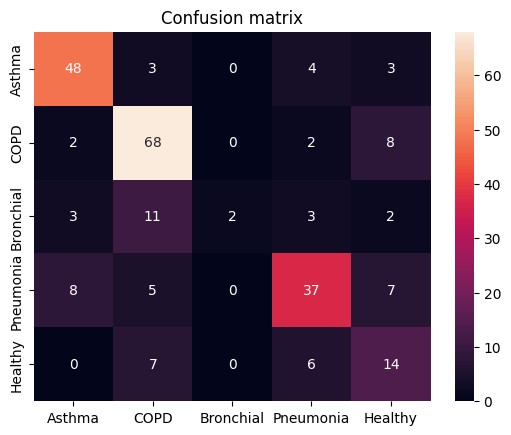

In [28]:
model.eval()
true_labels, pred_labels = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(CONFIG["DEVICE"]), yb.to(CONFIG["DEVICE"])
        outputs = model(xb)
        true_labels += yb.cpu().tolist()
        pred_labels += outputs.argmax(1).cpu().tolist()

print(classification_report(true_labels, pred_labels, target_names=CONFIG["CLASSES"]))
cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CONFIG["CLASSES"], yticklabels=CONFIG["CLASSES"])
plt.title("Confusion matrix")
plt.show()
